In [2]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Lecture 6: Census #

Creating a census: The process of collecting data about

Problems with the census data collection:

Load in the 2019 U.S. Census Data and describe the table.

Understanding the column variables:
* SEX
* AGE




In [3]:
full = Table.read_table('nc-est2019-agesex-res.csv')
full

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323
0,5,4056858,4056872,4064521,4087054,4131049,4121876,4004576,4017589,4035033,4003452,4008443,4028281
0,6,4066381,4066412,4072904,4074531,4096631,4141126,4133372,4017388,4031568,4048018,4014057,4017227
0,7,4030579,4030594,4042990,4082821,4084175,4106756,4152666,4145872,4030888,4044139,4058370,4022319
0,8,4046486,4046497,4025501,4052773,4092559,4094513,4118349,4165033,4158848,4042924,4054236,4066194
0,9,4148353,4148369,4125312,4035319,4062726,4103052,4106068,4130887,4177895,4170813,4053179,4061874


In [4]:
# Select only the 2014 and 2019 population estimates.

partial = full.select('SEX', 'AGE', 'POPESTIMATE2014', 'POPESTIMATE2019')
partial.show(5)

SEX,AGE,POPESTIMATE2014,POPESTIMATE2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323


In [5]:
# Relabel the column titles for easy reading.
us_pop = partial.relabeled(2, '2014').relabeled(3, '2019')
us_pop.show(5)

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323


In [6]:
# From the newly created table, find the records for the ages over 100.
us_pop.where('AGE', are.above_or_equal_to(100)).sort('AGE')

SEX,AGE,2014,2019
0,100,70685,100322
1,100,13577,23472
2,100,57108,76850
0,999,318301008,328239523
1,999,156654424,161657324
2,999,161646584,166582199


***QUESTION: What do these categories represent?***

### Percent Change ###

The amount of increase or decrease relative to the initial value.</br>
$\%Change = \dfrac{new - old}{old}*100$

In [8]:
# Percent Change in Population from 2014 to 2019
us_pop.with_column(
    '% Diff', ( us_pop.column('2019') - us_pop.column('2014') ) / us_pop.column('2014')
).set_format('% Diff', PercentFormatter)


SEX,AGE,2014,2019,% Diff
0,0,3954787,3783052,-4.34%
0,1,3948891,3829599,-3.02%
0,2,3958711,3922044,-0.93%
0,3,4005928,3998665,-0.18%
0,4,4004032,4043323,0.98%
0,5,4004576,4028281,0.59%
0,6,4133372,4017227,-2.81%
0,7,4152666,4022319,-3.14%
0,8,4118349,4066194,-1.27%
0,9,4106068,4061874,-1.08%


### 2019 Sex Ratios ###

Ratio: 

Proportion:

For this section we will only focus on the 2019 values.

In [11]:
# COMPLETE: Drop the 2014 information from the table.
us_pop_2019 = us_pop.drop('2014')
us_pop_2019.show(3)

SEX,AGE,2019
0,0,3783052
0,1,3829599
0,2,3922044


In [13]:
# COMPLETE: Create a table from 2019 table that only displays the age category for the entire population.
all_ages = us_pop_2019.where('AGE', are.equal_to(999))
all_ages

SEX,AGE,2019
0,999,328239523
1,999,161657324
2,999,166582199


***QUESTION: How would you calculate the proportion of for each row?***


In [15]:
# Add a proportion column to easily see which gender has more
pop_2019 = all_ages.column('2019').item(0)
all_ages.with_column(
    'Proportion', all_ages.column('2019')/pop_2019
).set_format('Proportion', PercentFormatter)

SEX,AGE,2019,Proportion
0,999,328239523,100.00%
1,999,161657324,49.25%
2,999,166582199,50.75%


***QUESTION: Which gender has the higher overall proportion?***

***QUESTION: If we focused on different age ranges, do you think it will be consistent from 0 to 100?***

Let's start by looking at the preteen age group.

In [16]:
preteen = us_pop_2019.where('AGE', are.between(10, 13))
preteen

SEX,AGE,2019
0,10,4060940
0,11,4189261
0,12,4208387
1,10,2071778
1,11,2138037
1,12,2149819
2,10,1989162
2,11,2051224
2,12,2058568


***QUESTION: Looking at each age represented in the table, what observations could be made?***


In [30]:
# COMPLETE: Create a table that contains all of the females from the 2019 table.
females_all_rows = us_pop_2019.where('SEX', are.equal_to(2))

# COMPLETE: Create a new table from the table you just created that does only includes valid ages.
females = females_all_rows.where('AGE', are.not_equal_to(999))
females.show(3)

SEX,AGE,2019
2,0,1847935
2,1,1871014
2,2,1916500


In [31]:
# COMPLETE: Create a table that contains all of the males from the 2019 table for all valid ages.
males_all_rows = us_pop_2019.where('SEX', are.equal_to(1))
males = males_all_rows.where('AGE', are.not_equal_to(999))
males.show(3)

SEX,AGE,2019
1,0,1935117
1,1,1958585
1,2,2005544


***QUESTION: Based on the tables above, what questions could be asked?***


### $F:M$ Ratios ###
$F:M$ means

Statistically, we know that women outlive men. Let's explore that.

* If $F = M$ then
* If $F > M$ then
* If $F < M$ then

We will create a table that shows the $F:M$ ratio for each age group.

In [25]:
f_to_m_ratios = females.column(2) / males.column(2)

ratios = Table().with_columns(
    'Age', females.column('AGE'),
    'F:M Ratio', f_to_m_ratios
)

In [24]:
ratios.sort('Age', descending=False)

Age,F:M Ratio
0,0.954947
1,0.955289
2,0.955601
3,0.957242
4,0.956177
5,0.954338
6,0.956801
7,0.956633
8,0.955161
9,0.959278


***QUESTION: What do you notice? What questions does that bring up?***


***QUESTION: What are your hypotheses?***

Let's look at the ratios of the preteen group.

In [26]:
ratios.sort('Age').take(np.arange(10,13 ))

Age,F:M Ratio
10,0.960123
11,0.959396
12,0.957554


***QUESTION: Since women outlive men, where do you think the change to more women than men occurs?***

Explore different age ranges and see what you can find.

***QUESTION: What age range seems to be where the switch happens? What hypotheses do you have as to why that happens?***

## Line Plot
Displaying data in an easy to read format.


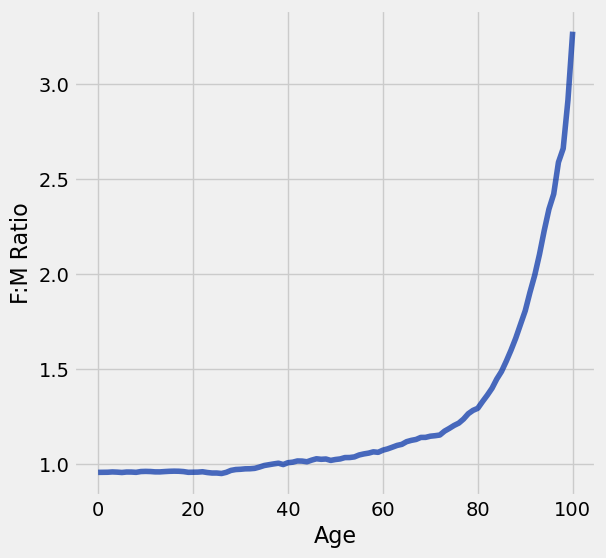

In [27]:
ratios.plot('Age', 'F:M Ratio')


***QUESTION: What do you notice about the scale of the axes in the line plot?***

***QUESTION: Why might it be helpful to have this view of the axes?***

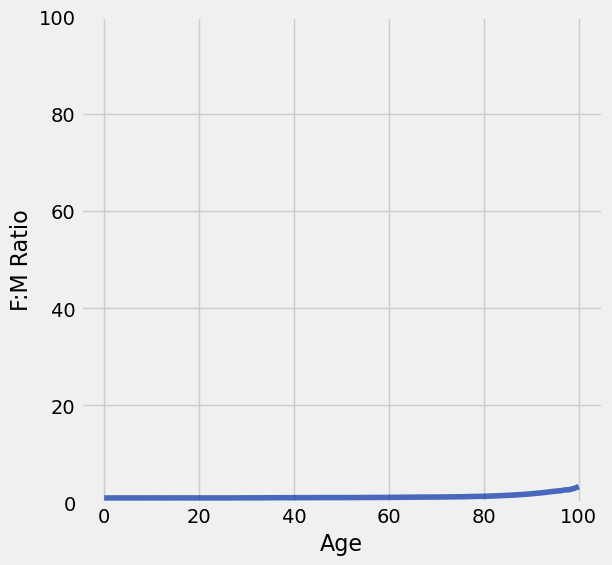

In [29]:
ratios.plot('Age', 'F:M Ratio')
plots.ylim(0, 100) # Sets y-axis from 0 to 100
plots.show()

***QUESTION: What do you notice when the x- and y-axis are the same scale?***

***QUESTION: What questions or observations can be made about this data after looking at the two graphs? List as many as you can think of.***